In [1]:
# This is an example of the code used to grid search through the FFNN written by Barrett Viator...
# it takes a very long time to execute the computations and is here as an example but not used in final code

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import ReLU
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping# Added for tuning
import matplotlib.pyplot as plt
import pyhere

In [3]:
train_path = pyhere.here('Data', 'train_data.xlsx')
test_path = pyhere.here('Data', 'test_data.xlsx')
train_data = pd.read_excel(train_path)
test_data = pd.read_excel(test_path)
# Use dropna() to remove any rows with missing values
train_data = train_data.dropna()
test_data = test_data.dropna()
print(train_data.head())

            CountryName CountryCode  year  HDI_Index  \
0   Antigua and Barbuda         ATG  2022      0.848   
9   Antigua and Barbuda         ATG  2008      0.830   
10  Antigua and Barbuda         ATG  2009      0.827   
11  Antigua and Barbuda         ATG  2010      0.828   
12  Antigua and Barbuda         ATG  2011      0.828   

                   HDI_Category  FoodIndex  ElectricAccess  PopDensity  \
0   Very high human development      89.95           100.0  211.000000   
9   Very high human development     145.98           100.0  188.436364   
10  Very high human development     141.40            98.5  191.302273   
11  Very high human development     102.49            98.7  193.909091   
12  Very high human development     104.99            94.6  196.209091   

    PopInSlums  WaterStress  ...  IncomeGroup  YearlyChgInternet  \
0     2.646340     8.461538  ...  High income           0.997844   
9     2.646317     9.230769  ...  High income           3.164091   
10    2.646311

In [4]:
train_target = train_data['HDI_Index']
test_target = test_data['HDI_Index']

train_predictors = train_data.drop('HDI_Index', axis=1)
test_predictors = test_data.drop('HDI_Index', axis=1)

train_predictors = train_data[['CountryCode', 'FoodIndex', 'ElectricAccess', 'PopDensity', 'PopInSlums', 'WaterStress', 'InternetUsersPct', 
                               'GDPPerCapGrowth', 'GDPGrowth', 'GDP', 'PoliticalStability', 'RqdEduYears', 'GovtEduSpendPctGDP', 
                               'UHCServiceCoverage', 'RuralPopulGrowth', 'VoiceAccountability']]

test_predictors = test_data[['CountryCode', 'FoodIndex', 'ElectricAccess', 'PopDensity', 'PopInSlums', 'WaterStress', 'InternetUsersPct', 
                             'GDPPerCapGrowth', 'GDPGrowth', 'GDP', 'PoliticalStability', 'RqdEduYears', 'GovtEduSpendPctGDP', 
                             'UHCServiceCoverage', 'RuralPopulGrowth', 'VoiceAccountability']]


In [5]:
# Combine the predictor data frames to ensure consistent encoding
combined_predictors = pd.concat([train_predictors, test_predictors], ignore_index=True)

# Identify numerical and categorical columns
numerical_cols = combined_predictors.select_dtypes(include=np.number).columns
categorical_cols = combined_predictors.select_dtypes(include='object').columns

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the combined numerical data to learn the min/max values
combined_predictors[numerical_cols] = scaler.fit_transform(combined_predictors[numerical_cols])

# Initialize OneHotEncoder to create sparse output and handle unknown categories
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit the encoder on the combined data to learn all possible categories
combined_categorical_encoded = ohe.fit_transform(combined_predictors[categorical_cols])

# Combine the encoded categorical data with the numerical data
combined_features = np.concatenate([combined_predictors[numerical_cols].values, 
                                    combined_categorical_encoded], axis=1)

# Split the combined feature matrix back into training and test sets
train_features = combined_features[:len(train_predictors)]
test_features = combined_features[len(train_predictors):]

# Features split
train_features, test_features, train_target, test_target = train_test_split(
    combined_features, train_target, test_size=0.2, random_state=42
)

In [6]:
# Hyperparameter tuning with grid search
hyper_grid = {
    'epochs': [1000, 2000],
    'batch_size': [16, 32, 64, 128],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1]
}
results = []


Training with epochs=1000, batch_size=16, lr=0.0001


C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with epochs=1000, batch_size=16, lr=0.001


C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with epochs=1000, batch_size=16, lr=0.01


...


Training with epochs=2000, batch_size=128, lr=0.1


C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



All Hyperparameter Results:
    epochs  batch_size  learning_rate      loss       mae
0     1000          16         0.0001  0.006557  0.006557
1     1000          16         0.0010  0.006885  0.006885
2     1000          16         0.0100  0.009586  0.009586
3     1000          16         0.1000  0.130775  0.130775
4     1000          32         0.0001  0.006877  0.006877
5     1000          32         0.0010  0.006661  0.006661
6     1000          32         0.0100  0.011462  0.011462
7     1000          32         0.1000  0.130820  0.130820
8     1000          64         0.0001  0.006984  0.006984
9     1000          64         0.0010  0.007646  0.007646
10    1000          64         0.0100  0.013756  0.013756
11    1000          64         0.1000  0.073112  0.073112
12    1000         128         0.0001  0.008575  0.008575
13    1000         128         0.0010  0.012860  0.012860
14    1000         128         0.0100  0.011175  0.011175
15    1000         128         0.1000  0.09

C:\Users\barre\my_new_env2\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0750 - mae: 0.0750 - val_loss: 0.0493 - val_mae: 0.0493
Epoch 2/1000
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0446 - mae: 0.0446 - val_loss: 0.0676 - val_mae: 0.0676
Epoch 3/1000
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0361 - mae: 0.0361 - val_loss: 0.0533 - val_mae: 0.0533
Epoch 4/1000
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0336 - mae: 0.0336 - val_loss: 0.0345 - val_mae: 0.0345
Epoch 5/1000
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0329 - mae: 0.0329 - val_loss: 0.0454 - val_mae: 0.0454
Epoch 6/1000
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0301 - mae: 0.0301 - val_loss: 0.0194 - val_mae: 0.0194
Epoch 7/1000
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0292 - mae: 0.0292 - val_loss: 0.0242 - val_mae: 0.0242
Epoch 8/1000
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0283 - mae: 0.0283 - val_loss: 0.0334 - val_mae: 0.0334
Epoch 9/1000
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

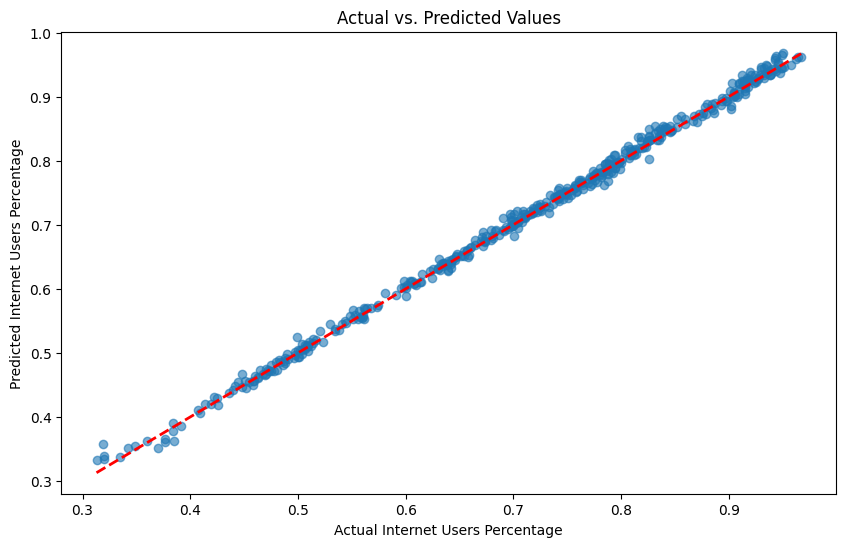

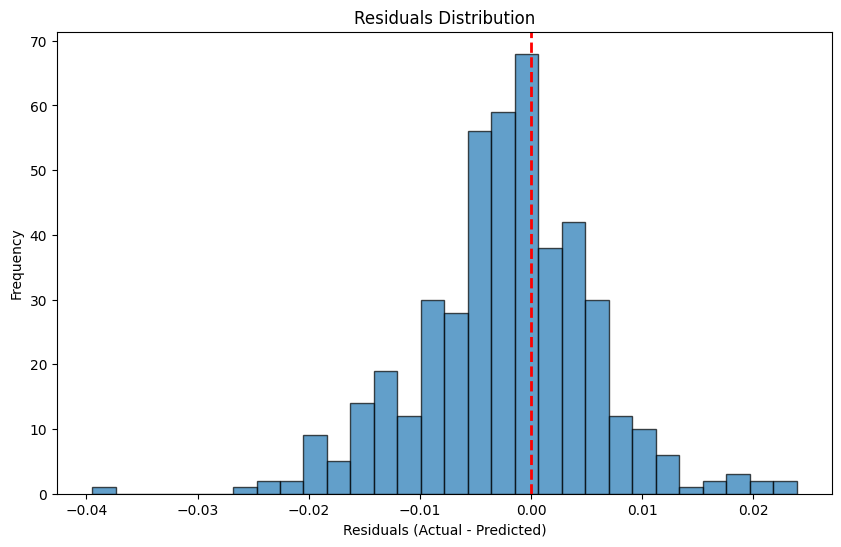

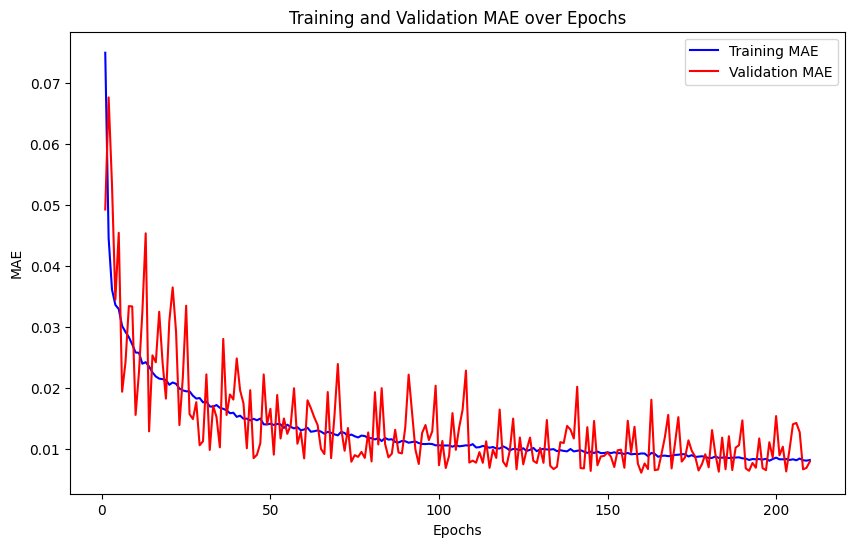

In [7]:
# Hyperparameter tuning loop
for epochs in hyper_grid['epochs']:
    for batch_size in hyper_grid['batch_size']:
        for lr in hyper_grid['learning_rate']:
            print(f"\nTraining with epochs={epochs}, batch_size={batch_size}, lr={lr}")

            model = Sequential()
            model.add(Dense(64, input_dim=train_features.shape[1]))
            model.add(ReLU())
            model.add(Dense(32))
            model.add(ReLU())
            model.add(Dense(1, activation='linear'))

            optimizer = RMSprop(learning_rate=lr)
            model.compile(optimizer=optimizer, loss='mean_absolute_error', metrics=['mae'])

            early_stop = EarlyStopping(monitor='val_loss', patience=50, verbose=0, restore_best_weights=True)

            history = model.fit(
                train_features, train_target,
                epochs=epochs,
                batch_size=batch_size,
                validation_split=0.2,
                callbacks=[early_stop],
                verbose=0
            )

            # Evaluate safely
            if test_features.shape[0] == 0 or test_target.shape[0] == 0:
                print("Skipping evaluation: Test data is empty.")
                loss, mae = None, None
            else:
                eval_results = model.evaluate(test_features, test_target, verbose=0)

                if isinstance(eval_results, (list, tuple)):
                    if len(eval_results) >= 2:
                        loss, mae = eval_results[0], eval_results[1]
                    elif len(eval_results) == 1:
                        loss, mae = eval_results[0], None
                    elif len(eval_results) == 0:
                        print("evaluate() returned empty list. Setting loss/mae = None.")
                        loss, mae = None, None
                else:
                    loss, mae = eval_results, None

            results.append({
                'epochs': epochs,
                'batch_size': batch_size,
                'learning_rate': lr,
                'loss': loss,
                'mae': mae
            })

# Put results in DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.dropna(subset=['loss'])

if not results_df.empty:
    print("\nAll Hyperparameter Results:")
    print(results_df)

    best_params = results_df.loc[results_df['loss'].idxmin()]
    print("\nBest Hyperparameters Found:")
    print(best_params)

    # Train the Final Model with Best Parameters
    print("\nTraining final model with best parameters...")
    final_model = Sequential()
    final_model.add(Dense(256, input_dim=train_features.shape[1], activation='relu'))
    final_model.add(Dense(128, activation='relu'))
    final_model.add(Dense(64, activation='relu'))
    final_model.add(Dense(1, activation='linear'))

    final_optimizer = RMSprop(learning_rate=best_params['learning_rate'])
    final_model.compile(optimizer=final_optimizer, loss='mean_absolute_error', metrics=['mae'])

    early_stop_final = EarlyStopping(monitor='val_loss', patience=50, verbose=1, restore_best_weights=True)

    final_history = final_model.fit(
        train_features, train_target,
        epochs=1000,
        batch_size=int(best_params['batch_size']),
        validation_data=(test_features, test_target),
        callbacks=[early_stop_final],
        verbose=1
    )

    # Final Evaluation
    if test_features.shape[0] == 0 or test_target.shape[0] == 0:
        print("Skipping final evaluation: Test data is empty.")
        loss_final, mae_final = None, None
    else:
        eval_results_final = final_model.evaluate(test_features, test_target, verbose=0)

        if isinstance(eval_results_final, (list, tuple)):
            if len(eval_results_final) >= 2:
                loss_final, mae_final = eval_results_final[0], eval_results_final[1]
            elif len(eval_results_final) == 1:
                loss_final, mae_final = eval_results_final[0], None
            elif len(eval_results_final) == 0:
                print("evaluate() returned empty list for final model.")
                loss_final, mae_final = None, None
        else:
            loss_final, mae_final = eval_results_final, None

        if loss_final is not None:
            print(f"\nFinal Model Loss on Test Data: {loss_final:.4f}")
        if mae_final is not None:
            print(f"Final Model MAE on Test Data: {mae_final:.4f}")

        # Predictions and Plots
        predictions = final_model.predict(test_features)
        if not np.any(np.isnan(predictions)):
            predictions = predictions.flatten()
            final_results_df = pd.DataFrame({'Actual': test_target, 'Predicted': predictions})

            # Scatter plot
            plt.figure(figsize=(10, 6))
            plt.scatter(final_results_df['Actual'], final_results_df['Predicted'], alpha=0.6)
            plt.plot([min(final_results_df['Actual']), max(final_results_df['Actual'])],
                     [min(final_results_df['Actual']), max(final_results_df['Actual'])],
                     color='red', linestyle='--', lw=2)
            plt.title('Actual vs. Predicted Values')
            plt.xlabel('Actual Internet Users Percentage')
            plt.ylabel('Predicted Internet Users Percentage')
            plt.show()

            # Residual plot
            final_results_df['Residuals'] = final_results_df['Actual'] - final_results_df['Predicted']
            plt.figure(figsize=(10, 6))
            plt.hist(final_results_df['Residuals'], bins=30, edgecolor='black', alpha=0.7)
            plt.axvline(x=0, color='red', linestyle='--', lw=2)
            plt.title('Residuals Distribution')
            plt.xlabel('Residuals (Actual - Predicted)')
            plt.ylabel('Frequency')
            plt.show()

            # Training & validation MAE
            mae_history = final_history.history['mae']
            val_mae_history = final_history.history['val_mae']
            epochs_range = range(1, len(mae_history) + 1)
            plt.figure(figsize=(10, 6))
            plt.plot(epochs_range, mae_history, 'b', label='Training MAE')
            plt.plot(epochs_range, val_mae_history, 'r', label='Validation MAE')
            plt.title('Training and Validation MAE over Epochs')
            plt.xlabel('Epochs')
            plt.ylabel('MAE')
            plt.legend()
            plt.show()
        else:
            print("Predictions contain invalid values (NaN or infinity). Cannot plot.")
else:
    print("No valid results found. Cannot train final model.")
